# Skforecast - Model Explainability


Reproduksi dan analisis berdasarkan dokumentasi resmi Skforecast:

https://skforecast.org/0.15.1/user_guides/explainability.html

Notebook ini bertujuan untuk mereproduksi contoh explainability pada model forecasting menggunakan library Skforecast. Analisis dilakukan untuk memahami faktor-faktor yang memengaruhi hasil prediksi melalui beberapa metode interpretasi model seperti Feature Importance, Permutation Importance, SHAP Values, dan Partial Dependence Plot (PDP). Dengan pendekatan ini, model tidak hanya menghasilkan prediksi, tetapi juga memberikan penjelasan mengenai kontribusi setiap fitur terhadap hasil yang diperoleh.

## 1. Analisis Prediksi: 

Studi kasus ini menganalisis **prediksi konsumsi listrik (electricity demand)** harian, yang merupakan data **time series univariat** dengan tambahan variabel eksogen (exogenous variables).

Tujuan utamanya adalah:
- Membangun model **forecasting autoregresif** menggunakan `ForecasterRecursive` dari skforecast dengan regressor `LGBMRegressor`
- **Menjelaskan (explain)** mengapa model membuat prediksi tertentu, bukan hanya menghasilkan angka prediksi
- Memahami **fitur mana yang paling berpengaruh** terhadap prediksi menggunakan teknik interpretabilitas:
  - Feature Importance (bawaan model)
  - SHAP Values (SHapley Additive exPlanations)
  - Permutation Importance
  - Partial Dependence Plot (PDP)

## 2. Struktur Data Training

### 2.1 Konsep Transformasi Time Series → Supervised Learning

Skforecast mengubah masalah **time series** menjadi masalah **supervised machine learning** dengan cara:

$$
\text{Time Series: } y_1, y_2, y_3, \ldots, y_t
$$

Diubah menjadi tabel fitur–target:

$$
\underbrace{(y_{t-p}, y_{t-p+1}, \ldots, y_{t-1})}_{\text{INPUT (lag features)}} \xrightarrow{\text{model}} \underbrace{y_t}_{\text{OUTPUT (target)}}
$$

### 2.2 Input (Fitur / Kolom X)

| Jenis Fitur | Contoh Kolom | Deskripsi |
|---|---|---|
| **Lag features** | `lag_1`, `lag_2`, ..., `lag_24` | Nilai konsumsi listrik $p$ langkah ke belakang |
| **Exogenous variables** | `temperature`, `hour`, `dayofweek`, dll. | Variabel eksternal yang mempengaruhi konsumsi |

### 2.3 Output (Target / Kolom y)

$$
y = \text{konsumsi listrik pada waktu } t
$$

> Setiap baris pada matriks training mewakili **satu jendela waktu (window)**, di mana input adalah nilai historis dan output adalah nilai yang ingin diprediksi.

## 3. Pengertian Lag

**Lag** adalah nilai dari time series pada waktu-waktu sebelumnya yang digunakan sebagai fitur (input) untuk memprediksi nilai saat ini.

$$
\text{lag}_k = y_{t-k}
$$

**Contoh konkret:** Jika kita memprediksi konsumsi listrik jam 10:00, maka:

$$
\text{lag}_1 = y_{\text{jam 09:00}}, \quad \text{lag}_2 = y_{\text{jam 08:00}}, \quad \text{lag}_{24} = y_{\text{jam 10:00 hari kemarin}}
$$

**Mengapa lag penting?**
- Time series memiliki **autokorelasi** — nilai saat ini dipengaruhi nilai masa lalu
- Lag menangkap **pola periodik** (harian, mingguan, musiman)
- Semakin banyak lag yang digunakan, semakin jauh model "melihat" ke masa lalu

Dalam skforecast, kita mendefinisikan lag dengan parameter `lags=24` (misalnya), artinya model menggunakan 24 nilai historis terakhir sebagai fitur.

## 4. Instalasi Library

menggunakan kode kombinasi sys.executable dan --user dikarenakan, perintah instalasi biasa diblokir (Access is denied) oleh laptop karena folder utama Python dikunci oleh sistem Windows. Agar program berjalan lancar tanpa eror, perintah sys.executable digunakan untuk mengarahkan instalasi agar tepat sasaran pada Python yang sedang aktif di Jupyter Notebook, sedangkan bagian --user bertugas memindahkan lokasi penyimpanannya ke folder akun pribadi kita.

In [120]:
# Jalankan ini di cell paling pertama untuk mengizinkan instalasi tanpa hambatan 'Access Denied'
import sys
!{sys.executable} -m pip install skforecast==0.15.1 shap lightgbm matplotlib scikit-learn pandas numpy --user

## 5. Import Library & Load Data

In [82]:
# Menonaktifkan warning agar output lebih bersih
import warnings
warnings.filterwarnings('ignore')

# Library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap

# Library explainability
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Model machine learning
from lightgbm import LGBMRegressor

# Library forecasting
from skforecast.recursive import ForecasterRecursive
from skforecast.datasets import fetch_dataset

# Inisialisasi SHAP
shap.initjs()

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


#### Pemuatan Dataset Konsumsi Listrik (Vic Electricity)

Tahap awal dimulai dengan mengunduh dan memuat dataset mentah (*raw data*) `vic_electricity` menggunakan fungsi `fetch_dataset` dari pustaka `skforecast`. Dataset historis ini berisi data konsumsi listrik di wilayah Victoria, Australia, yang mencakup variabel utama seperti tingkat permintaan listrik (`Demand`) dan suhu udara (`Temperature`). Fungsi `data.head(10)` kemudian digunakan untuk menampilkan 10 baris pertama data guna memeriksa struktur awal dan gambaran umum isi dataset.

In [83]:
# Memuat dataset konsumsi listrik
data = fetch_dataset(name='vic_electricity', raw=True)

data.head(10)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 5)


,Time,Demand,Temperature,Date,Holiday
0,2011-12-31T13:00:00Z,4382.825174,21.40,2012-01-01,True
1,2011-12-31T13:30:00Z,4263.365526,21.05,2012-01-01,True
2,2011-12-31T14:00:00Z,4048.966046,20.70,2012-01-01,True
3,2011-12-31T14:30:00Z,3877.563330,20.55,2012-01-01,True
4,2011-12-31T15:00:00Z,4036.229746,20.40,2012-01-01,True
5,2011-12-31T15:30:00Z,3865.597244,20.25,2012-01-01,True
6,2011-12-31T16:00:00Z,3694.097664,20.10,2012-01-01,True
7,2011-12-31T16:30:00Z,3561.623686,19.60,2012-01-01,True
8,2011-12-31T17:00:00Z,3433.035352,19.10,2012-01-01,True
9,2011-12-31T17:30:00Z,3359.468000,18.95,2012-01-01,True


#### Eksplorasi Dimensi, Tipe Data, dan Rentang Waktu

Tahap ini bertujuan untuk memeriksa karakteristik dasar dari dataset yang telah diproses. Kode ini menampilkan **dimensi data** (jumlah baris dan kolom), **tipe data** dari setiap variabel untuk memastikan kesesuaian format numerik, serta **rentang waktu** (tanggal awal hingga tanggal akhir) guna mengetahui cakupan periode waktu dari seluruh data historis konsumsi listrik yang tersedia.

In [84]:
# Melihat ukuran, tipe data, dan rentang waktu dataset
print(f"Shape data: {data.shape}")
print(f"Tipe data:\n{data.dtypes}")
print(f"\nRentang waktu: {data.index.min()} s/d {data.index.max()}")

Shape data: (52608, 5)
Tipe data:
Time            object
Demand         float64
Temperature    float64
Date            object
Holiday           bool
dtype: object

Rentang waktu: 0 s/d 52607


#### Preprocessing dan Penyiapan Data Waktu

Tahap ini dilakukan untuk membersihkan dan menstrukturkan data agar siap digunakan oleh model peramalan. Kode ini mendeteksi kolom waktu, mengubah formatnya menjadi tipe data `datetime` berbasis zona waktu UTC, serta menetapkannya sebagai indeks baris. Data kemudian diurutkan dan diseragamkan frekuensinya menjadi **per jam (hourly)** dengan metode rata-rata untuk mengisi kekosongan. Terakhir, dibuat tiga fitur eksogen baru berbasis waktu—yaitu jam (`hour`), hari (`dayofweek`), dan bulan (`month`)—untuk membantu model mengenali pola siklus konsumsi listrik harian hingga bulanan.

In [85]:
# Memastikan kolom waktu tersedia dan siap digunakan
import pandas as pd

if data.index.name == 'Time':
    data = data.reset_index()

data.columns = data.columns.str.strip()

# Mengubah kolom waktu menjadi datetime dan menjadikannya index
data['Time'] = pd.to_datetime(data['Time'], utc=True)
data = data.set_index('Time')

# Resample data menjadi per jam
data = data.asfreq('30min').sort_index()
data = data.resample('h').mean(numeric_only=True)
data = data.dropna()

# Menambahkan fitur waktu (exogenous features)
data['hour']      = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month']     = data.index.month

print(f"Shape setelah preprocessing: {data.shape}")
data.head()

Shape setelah preprocessing: (26304, 6)


,Demand,Temperature,Holiday,hour,dayofweek,month
Time,,,,,,
2011-12-31 13:00:00+00:00,4323.095350,21.225,1.0,13,5,12
2011-12-31 14:00:00+00:00,3963.264688,20.625,1.0,14,5,12
2011-12-31 15:00:00+00:00,3950.913495,20.325,1.0,15,5,12
2011-12-31 16:00:00+00:00,3627.860675,19.850,1.0,16,5,12
2011-12-31 17:00:00+00:00,3396.251676,19.025,1.0,17,5,12


#### Pembuatan dan Pelatihan Model Prediksi Data Harian

Pada tahap ini, data harian dibagi menjadi dua bagian: **data latih** (sebelum 22 Desember 2014) untuk melatih model dan **data uji** untuk mengevaluasi performa. Peramalan dilakukan menggunakan `ForecasterRecursive` dengan algoritma dasar `LGBMRegressor` (LightGBM). Model ini dilatih menggunakan data masa lalu hingga 7 hari ke belakang (`lags = 7`) serta memanfaatkan informasi suhu udara (`Temperature`) sebagai variabel eksogen untuk memprediksi total konsumsi listrik harian (`Demand`).

In [86]:
# 1. Agregasikan data per jam lama menjadi data harian terlebih dahulu
data_daily = data.resample('D').mean()

# 2. Split train-test menggunakan data harian yang baru dibuat
data_train_daily = data_daily.loc[: '2014-12-21']
data_test_daily  = data_daily.loc['2014-12-22':]

# 3. Membuat model recursive forecaster untuk data harian
forecaster_daily = ForecasterRecursive(
                     regressor = LGBMRegressor(random_state=123, verbose=-1),
                     lags      = 7
                 )

# 4. Melatih model menggunakan data harian
forecaster_daily.fit(
    y    = data_train_daily['Demand'],
    exog = data_train_daily['Temperature']
)

# 5. Menampilkan informasi model harian
display(forecaster_daily)

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00+0000', tz='UTC'), Timestamp('2014-12-21 00:00:00+0000', tz='UTC')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 11:45:25 
Last fit date: 2026-06-11 11:45:25 
Skforecast version: 0.15.1 
Python version: 3.12.5 
Forecaster id: None

#### Analisis Tingkat Kepentingan Fitur Data Harian

Fungsi `get_feature_importances()` digunakan pada model harian (`forecaster_daily`) untuk mengukur seberapa besar kontribusi setiap variabel dalam memprediksi konsumsi listrik harian. Hasil dari kode ini akan menunjukkan faktor mana yang paling berpengaruh bagi model, apakah data historis listrik beberapa hari ke belakang (`lags`) atau variabel suhu udara (`Temperature`).

In [87]:
# Predictors importances untuk model harian
forecaster_daily.get_feature_importances()

,feature,importance
7,Temperature,577
0,lag_1,458
2,lag_3,387
1,lag_2,362
6,lag_7,328
5,lag_6,316
4,lag_5,307
3,lag_4,265


## 6. Visualisasi Data

Melihat pola konsumsi listrik untuk memahami karakteristik time series yang akan diprediksi. Tujuan dari visualisasi ini adalah untuk melihat pola naik-turunnya penggunaan listrik secara langsung. Grafik pertama digunakan untuk memantau **tren jangka panjang dan pengaruh musim** dalam setahun, sedangkan grafik kedua (zoom) digunakan untuk melihat **kebiasaan siklus harian** (jam beban puncak penggunaan listrik dalam sehari).

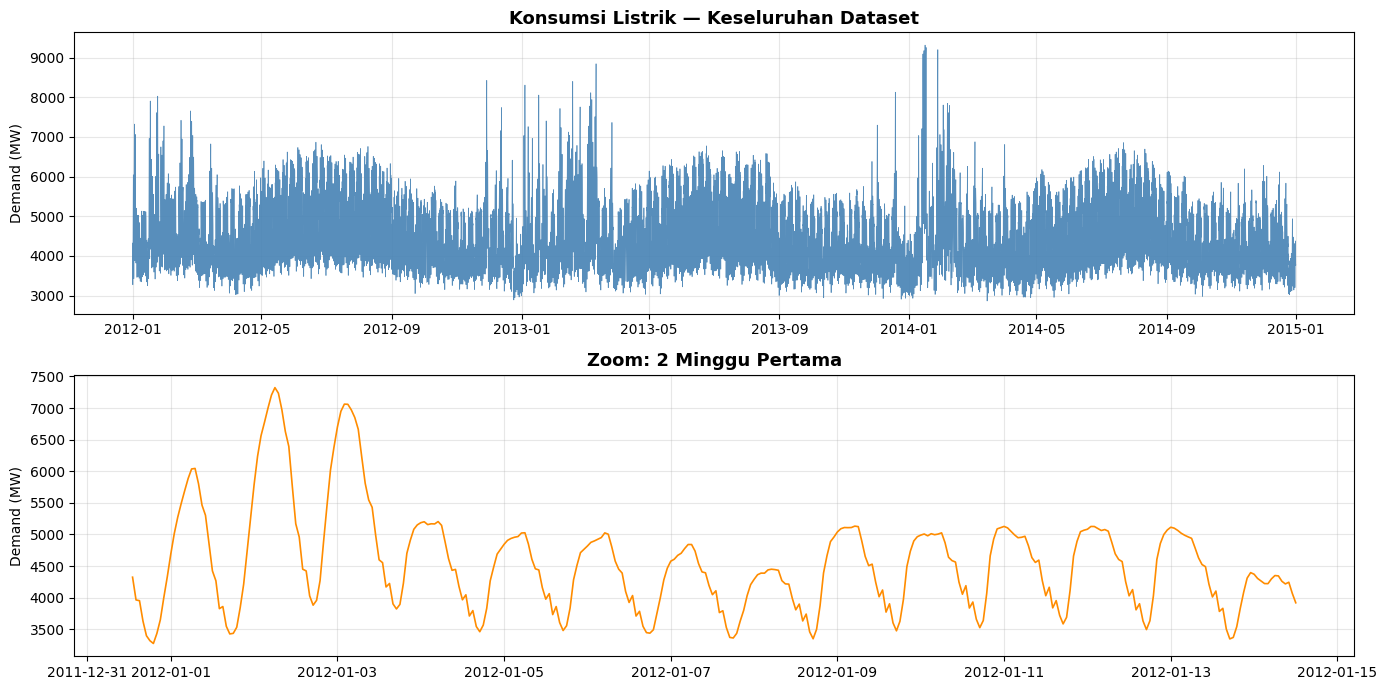

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot keseluruhan
axes[0].plot(data['Demand'], color='steelblue', linewidth=0.5, alpha=0.9)
axes[0].set_title('Konsumsi Listrik — Keseluruhan Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].grid(True, alpha=0.3)

# Plot zoom 2 minggu
zoom = data['Demand'].iloc[:24*14]
axes[1].plot(zoom, color='darkorange', linewidth=1.2)
axes[1].set_title('Zoom: 2 Minggu Pertama', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Split Data: Training & Test

Proses ini dilakukan untuk membagi dataset secara adil menjadi dua bagian, yaitu 90% untuk data training (data_train) dan 10% untuk data testing (data_test).

In [89]:
# Membagi dataset menjadi 90% data training dan 10% data testing
n = len(data)
cutoff = int(n * 0.9)

data_train = data.iloc[:cutoff].copy()
data_test  = data.iloc[cutoff:].copy()

print(f"Training: {data_train.index.min()} → {data_train.index.max()} ({len(data_train)} baris)")
print(f"Test    : {data_test.index.min()} → {data_test.index.max()} ({len(data_test)} baris)")

Training: 2011-12-31 13:00:00+00:00 → 2014-09-12 21:00:00+00:00 (23673 baris)
Test    : 2014-09-12 22:00:00+00:00 → 2014-12-31 12:00:00+00:00 (2631 baris)


## 8. Membangun Forecaster

### 8.1 Arsitektur Model

$$
\hat{y}_{t} = f\left(y_{t-1}, y_{t-2}, \ldots, y_{t-24},\ \text{hour}_t,\ \text{dayofweek}_t,\ \text{month}_t\right)
$$

Di mana $f$ adalah **LightGBM Regressor** (gradient boosted trees).

- `lags = 24`: gunakan 24 jam terakhir sebagai fitur lag
- Exogenous: `hour`, `dayofweek`, `month`

Proses ini dilakukan untuk membangun dan melatih mesin prediksi (model forecasting) bernama forecaster yang berbasis algoritma LightGBM Regressor.

In [90]:
# Membuat dan melatih model forecasting menggunakan LightGBM
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor

# Model menggunakan 7 lag (7 langkah sebelumnya) sebagai input
forecaster = ForecasterRecursive(
    LGBMRegressor(
        n_estimators   = 500,
        learning_rate  = 0.05,
        max_depth      = 6,
        random_state   = 42,
        verbose        = -1
    ),
    lags = 7
)

# KUNCI PERUBAHAN: Masukkan 'Temperature' ke dalam list variabel pendukung (exogenous)
exog_cols = ['hour', 'dayofweek', 'month', 'Temperature']

# Melatih model dengan menyertakan fitur Temperature
forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train[exog_cols]
)

print("Forecaster dengan Lag 1-7 dan Fitur Temperature berhasil dilatih!")
print(forecaster)

Forecaster dengan Lag 1-7 dan Fitur Temperature berhasil dilatih!
ForecasterRecursive 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: hour, dayofweek, month, Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 13:00:00+0000', tz='UTC'), Timestamp('2014-09-12 21:00:00+0000', tz='UTC')] 
Training index type: DatetimeIndex 
Training index frequency: h 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 500, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsampl

### 8.2 Visualisasi Matriks Training (X_train & y_train)

Mari kita lihat **bentuk nyata** dari data training yang dibentuk oleh skforecast:

In [91]:
# Membentuk data training (fitur dan target) untuk analisis explainability
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train[exog_cols]
)

print(f"Shape X_train (fitur): {X_train.shape}")
print(f"Shape y_train (target): {y_train.shape}")
print(f"\nKolom X_train: {list(X_train.columns)}")
print("\n5 Baris pertama X_train (Sampel Lag 1-7):")

# Hanya menampilkan kolom lag_1 sampai lag_7 dan fitur eksogen
kolom_tampil = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'hour', 'dayofweek', 'month']
X_train[kolom_tampil].head()

Shape X_train (fitur): (23666, 11)
Shape y_train (target): (23666,)

Kolom X_train: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'hour', 'dayofweek', 'month', 'Temperature']

5 Baris pertama X_train (Sampel Lag 1-7):


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,hour,dayofweek,month
Time,,,,,,,,,,
2011-12-31 20:00:00+00:00,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,3963.264688,4323.095350,20.0,5.0,12.0
2011-12-31 21:00:00+00:00,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,3963.264688,21.0,5.0,12.0
2011-12-31 22:00:00+00:00,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,3950.913495,22.0,5.0,12.0
2011-12-31 23:00:00+00:00,4000.933475,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,3627.860675,23.0,5.0,12.0
2012-01-01 00:00:00+00:00,4329.049863,4000.933475,3650.038153,3432.421122,3274.052232,3317.992230,3396.251676,0.0,6.0,1.0


In [92]:
# Menampilkan beberapa nilai target (Demand) yang digunakan saat training
print("5 baris pertama y_train (target = Demand):")
y_train.head()

5 baris pertama y_train (target = Demand):


Time
2011-12-31 20:00:00+00:00    3432.421122
2011-12-31 21:00:00+00:00    3650.038153
2011-12-31 22:00:00+00:00    4000.933475
2011-12-31 23:00:00+00:00    4329.049863
2012-01-01 00:00:00+00:00    4685.820480
Freq: h, Name: y, dtype: float64

## 9. Proses Analisis Explainability

### 9.1 Feature Importance (Bawaan Model)

LightGBM secara internal menghitung **seberapa sering** dan **seberapa besar** setiap fitur berkontribusi dalam pembentukan pohon keputusan.

$$
\text{Importance}(f_j) = \sum_{\text{trees}} \sum_{\text{splits}} \mathbb{1}[\text{fitur } f_j \text{ digunakan}] \times \Delta \text{impurity}
$$

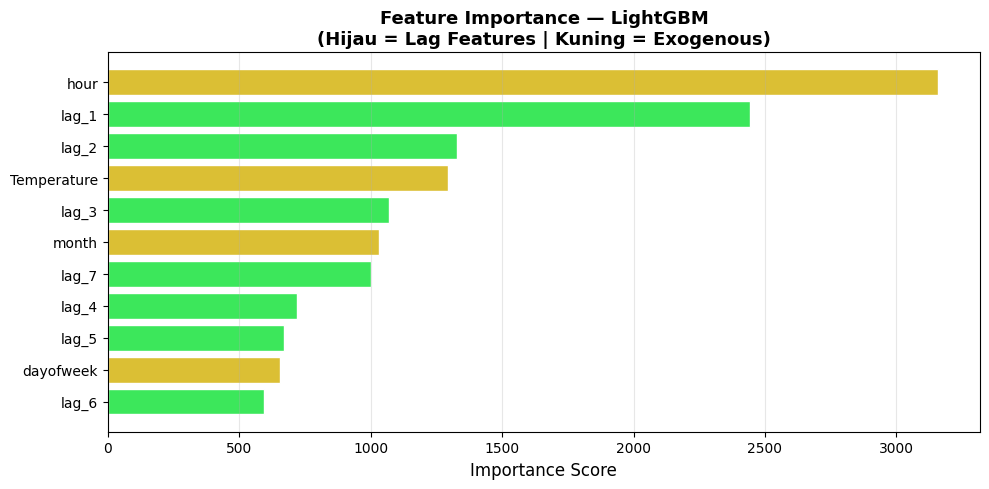


Top 10 fitur terpenting:
    feature  importance
       hour        3160
      lag_1        2443
      lag_2        1327
Temperature        1294
      lag_3        1071
      month        1031
      lag_7        1003
      lag_4         720
      lag_5         672
  dayofweek         654


In [93]:
# Menghitung dan mengurutkan feature importance dari model
importance_df = forecaster.get_feature_importances()
importance_df = importance_df.sort_values('importance', ascending=False)

# Membuat visualisasi feature importance (Ukuran diubah sedikit agar pas dengan jumlah fitur)
fig, ax = plt.subplots(figsize=(10, 5))

# Memisahkan warna untuk fitur Lag (Hijau) dan Eksogen (Kuning)
colors = ["#3ce75b" if 'lag' in f else "#dbbf34" for f in importance_df['feature']]

ax.barh(
    importance_df['feature'],
    importance_df['importance'],
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(
    'Feature Importance — LightGBM\n(Hijau = Lag Features | Kuning = Exogenous)',
    fontsize=13,
    fontweight='bold'
)

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Menampilkan 10 fitur yang paling berpengaruh terhadap prediksi
print("\nTop 10 fitur terpenting:")
print(importance_df.head(10).to_string(index=False))

### 9.2 SHAP Values (SHapley Additive exPlanations)

SHAP berasal dari **game theory** (Shapley values). Ide dasarnya: setiap fitur adalah "pemain" dalam permainan kooperatif, dan SHAP mengukur kontribusi adil setiap pemain terhadap prediksi.

$$
\hat{y}_i = \phi_0 + \sum_{j=1}^{p} \phi_{ij}
$$

Di mana:
- $\hat{y}_i$ = prediksi untuk sampel ke-$i$
- $\phi_0$ = nilai dasar (rata-rata prediksi model)
- $\phi_{ij}$ = kontribusi SHAP fitur ke-$j$ untuk sampel ke-$i$

**Properti penting:** Jumlah semua SHAP values selalu sama dengan selisih prediksi dengan rata-rata:
$$
\hat{y}_i - \mathbb{E}[\hat{y}] = \sum_{j=1}^{p} \phi_{ij}
$$

### Inisialisasi dan Perhitungan Nilai SHAP

Bagian ini digunakan untuk menghitung nilai SHAP dari model LightGBM menggunakan `TreeExplainer`. Nilai SHAP yang dihasilkan menunjukkan kontribusi setiap fitur terhadap prediksi model dan menjadi dasar untuk berbagai visualisasi interpretabilitas seperti summary plot, waterfall plot, dan force plot.

In [94]:
# Mengambil model LightGBM dari forecaster untuk analisis SHAP
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]

# Membuat SHAP TreeExplainer dan menghitung nilai SHAP
explainer = shap.TreeExplainer(internal_model)

# Menggunakan sebagian data training agar proses lebih cepat
X_sample = X_train.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Menampilkan ukuran hasil SHAP values
print(f"Shape SHAP values: {shap_values.shape}")
print(f"(baris = sampel, kolom = fitur)")

Shape SHAP values: (1000, 11)
(baris = sampel, kolom = fitur)


### SHAP Global Feature Importance (Bar Plot)

Visualisasi ini digunakan untuk melihat tingkat kepentingan fitur secara keseluruhan dalam model. Grafik batang menunjukkan fitur yang paling berpengaruh terhadap hasil prediksi berdasarkan rata-rata nilai SHAP absolut, sehingga dapat diketahui fitur mana yang paling dominan dalam proses prediksi.

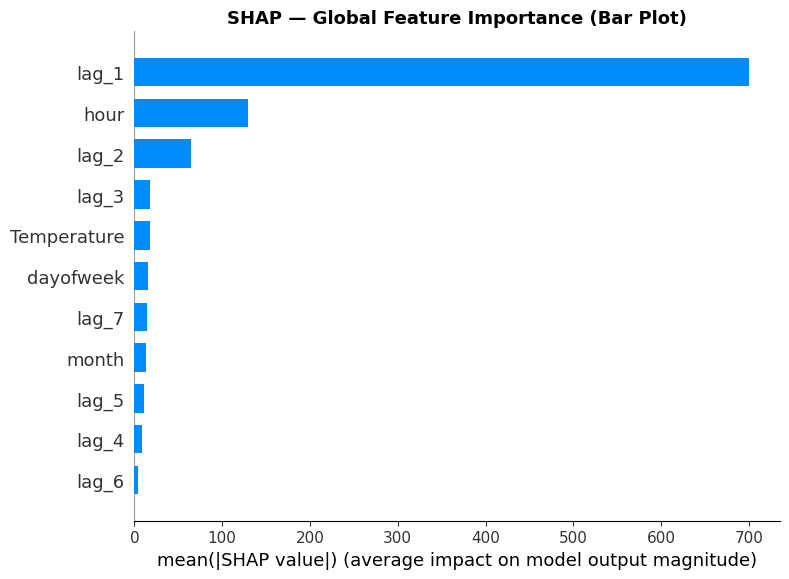

In [95]:
# Membuat visualisasi SHAP untuk melihat pengaruh fitur secara global
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)

plt.title(
    'SHAP — Global Feature Importance (Bar Plot)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### SHAP Beeswarm Plot

Visualisasi ini digunakan untuk melihat distribusi dan arah pengaruh setiap fitur terhadap prediksi model. Selain menunjukkan tingkat kepentingan fitur, grafik ini juga memperlihatkan apakah nilai fitur yang tinggi atau rendah cenderung meningkatkan atau menurunkan hasil prediksi.

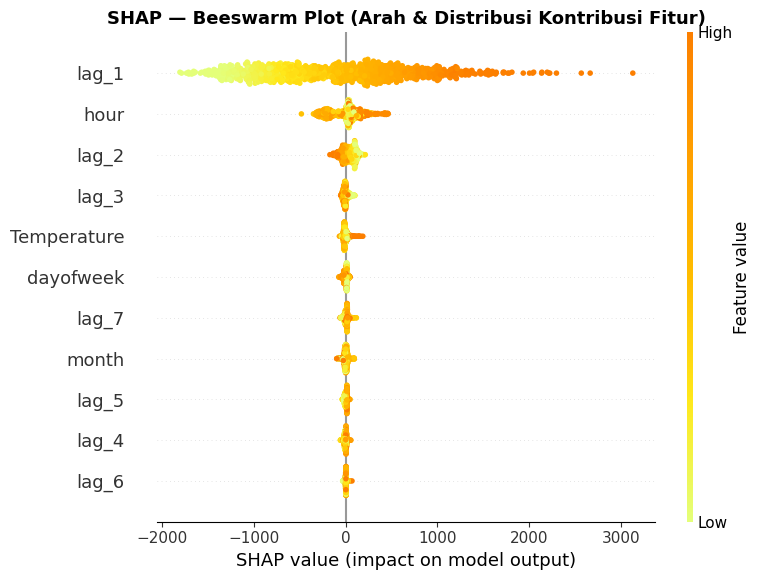

In [96]:
# Membuat visualisasi SHAP Beeswarm untuk melihat arah dan sebaran pengaruh fitur
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_sample,
    cmap='Wistia',
    show=False
)

plt.title(
    'SHAP — Beeswarm Plot (Arah & Distribusi Kontribusi Fitur)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Cara membaca Beeswarm Plot:**
- **Sumbu X** = nilai SHAP (positif = mendorong prediksi naik, negatif = mendorong turun)
- **Warna merah** = nilai fitur tinggi, **biru** = nilai fitur rendah
- **Titik tersebar** = distribusi kontribusi di seluruh sampel

### Analisis Prediksi Individual dengan SHAP Force Plot

Bagian ini bertujuan untuk membuat visualisasi interaktif **SHAP Force Plot** pada 200 sampel data pertama di dataset pelatihan, dengan cara memetakan nilai dasar model bersama kontribusi nilai SHAP dan fitur aslinya. Gunanya adalah untuk melakukan analisis lokal yang mendalam, sehingga kita bisa membongkar alasan di balik setiap prediksi model secara individu dan melihat jelas fitur mana saja (seperti faktor jam atau data *lag*) yang mendorong prediksi konsumsi listrik menjadi naik atau justru menariknya turun.

In [97]:
# Force plot for the first 200 observations in the training set
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[:200, :],
    X_train.iloc[:200, :]
)

### SHAP Waterfall Plot 

Visualisasi ini digunakan untuk menjelaskan satu prediksi tertentu dengan menunjukkan kontribusi masing-masing fitur terhadap hasil prediksi. Grafik memperlihatkan bagaimana setiap fitur memberikan pengaruh positif atau negatif hingga menghasilkan nilai prediksi akhir.

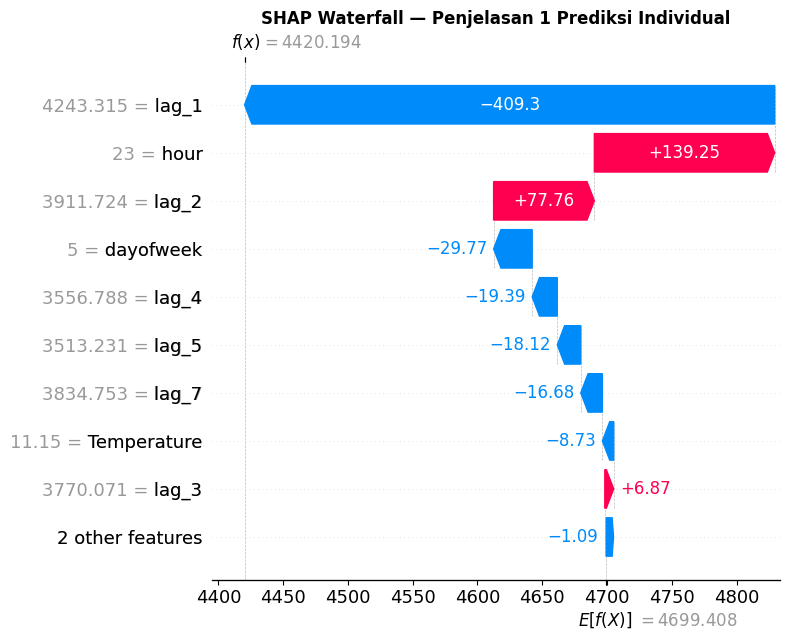

In [98]:
# SHAP Waterfall Plot 

idx = 0  # sampel ke-0
shap_explanation = shap.Explanation(
    values       = shap_values[idx],
    base_values  = explainer.expected_value,
    data         = X_sample.iloc[idx].values,
    feature_names= X_sample.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False)
plt.title('SHAP Waterfall — Penjelasan 1 Prediksi Individual', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Cara membaca Waterfall Plot:**
- **E[f(x)]** = rata-rata semua prediksi model (baseline)
- **f(x)** = prediksi akhir untuk sampel ini
- Setiap bar menunjukkan seberapa besar **satu fitur** mengubah prediksi dari baseline ke hasil akhir

### 9.3 Permutation Importance

Permutation importance mengukur **seberapa besar performa model menurun** ketika nilai sebuah fitur **diacak secara acak** (sehingga memutus hubungannya dengan target).

$$
\text{PI}(f_j) = \overline{\text{score}_{\text{baseline}}} - \overline{\text{score}_{\text{after permuting } f_j}}
$$

Semakin besar penurunan performa → semakin penting fitur tersebut.

### Permutation Importance

Visualisasi ini digunakan untuk mengukur tingkat kepentingan fitur dengan melihat perubahan performa model setelah nilai suatu fitur diacak. Semakin besar penurunan performa yang terjadi, semakin penting peran fitur tersebut dalam menghasilkan prediksi yang akurat.

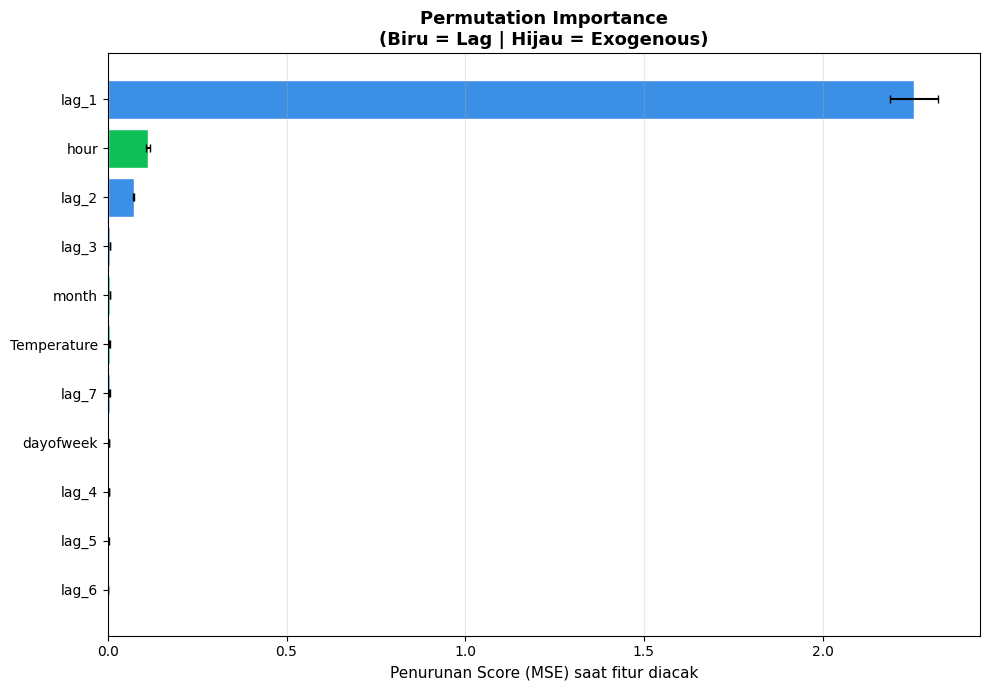

In [99]:
# Mengambil model LightGBM dari forecaster
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]


# Mengambil sampel data training agar proses lebih cepat
sample_size = min(1000, len(X_train))
X_sample_perm = X_train.sample(n=sample_size, random_state=42)
y_sample_perm = y_train.loc[X_sample_perm.index]


# Menghitung Permutation Importance
result = permutation_importance(
    estimator    = internal_model,
    X            = X_sample_perm,
    y            = y_sample_perm,
    n_repeats    = 5,
    random_state = 42,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'feature'           : X_sample_perm.columns,
    'importance_mean'   : result.importances_mean,
    'importance_std'    : result.importances_std
}).sort_values('importance_mean', ascending=False)

# Membuat visualisasi hasil Permutation Importance
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#3c8fe7" if 'lag' in f else "#0fc059" for f in perm_df['feature']]

ax.barh(
    perm_df['feature'],
    perm_df['importance_mean'],
    xerr  = perm_df['importance_std'],
    color = colors,
    edgecolor='white',
    capsize=3
)

ax.set_xlabel('Penurunan Score (MSE) saat fitur diacak', fontsize=11)
ax.set_title('Permutation Importance\n(Biru = Lag | Hijau = Exogenous)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.4 Partial Dependence Plot (PDP)

PDP menunjukkan **hubungan rata-rata** antara satu fitur dengan output prediksi, dengan mengisolasi efek fitur lain (dianggap konstan).

$$
\hat{f}_{x_j}(x_j) = \mathbb{E}_{X_{\setminus j}}\left[\hat{f}(x_j, X_{\setminus j})\right] = \frac{1}{n}\sum_{i=1}^{n} \hat{f}(x_j, x_{\setminus j}^{(i)})
$$

Di mana $X_{\setminus j}$ adalah semua fitur selain $x_j$.

### Partial Dependence Plot (PDP) Hubunagn Fitur Vs Prediksi

Visualisasi ini digunakan untuk menganalisis pengaruh suatu fitur terhadap hasil prediksi model. Grafik menunjukkan bagaimana perubahan nilai fitur dapat meningkatkan atau menurunkan nilai prediksi, sehingga hubungan antara fitur dan target dapat lebih mudah dipahami.

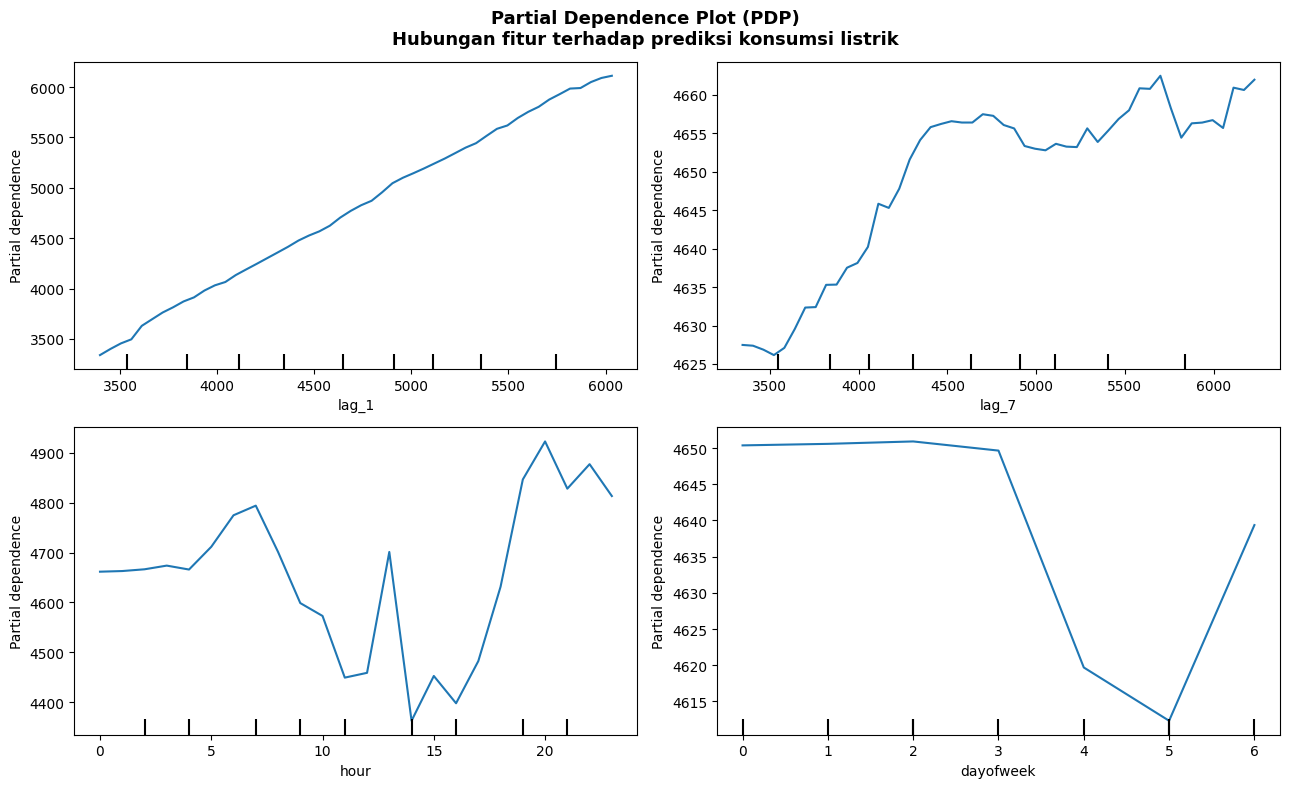

In [119]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Mengambil model LightGBM dari forecaster
if 'regressor' in vars(forecaster):
    internal_model = forecaster.regressor
elif '_regressor' in vars(forecaster):
    internal_model = forecaster._regressor
else:
    internal_model = [v for k, v in vars(forecaster).items() if 'Regressor' in type(v).__name__][0]

# Menggunakan data bersih dan sampling untuk PDP
X_train_float = X_train_clean.astype('float64')
sample_size = min(1000, len(X_train_float))
X_sample_pdp = X_train_float.sample(n=sample_size, random_state=42)

# Fitur yang dianalisis
top_features = ['lag_1', 'lag_7', 'hour', 'dayofweek']

# Membuat grafik PDP 2x2
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.ravel()

for i, feature in enumerate(top_features):
    PartialDependenceDisplay.from_estimator(
        estimator=internal_model,
        X=X_sample_pdp,
        features=[feature],
        feature_names=X_sample_pdp.columns.tolist(),
        ax=axes_flat[i],
        grid_resolution=50
    )

    # Menghapus legenda kosong
    if axes_flat[i].legend_:
        axes_flat[i].legend_.set_visible(False)

# Judul utama grafik
fig.suptitle(
    'Partial Dependence Plot (PDP)\nHubungan fitur terhadap prediksi konsumsi listrik',
    fontsize=13,
    fontweight='bold',
    y=0.98
)

# Styling grafik
for ax in axes_flat:
    ax.set_ylabel('Prediksi Demand (MW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### SHAP Force Plot Statis (1 Hari Prediksi)

Visualisasi ini digunakan untuk menjelaskan hasil prediksi pada satu hari tertentu dengan menunjukkan kontribusi masing-masing fitur terhadap nilai prediksi. Grafik memperlihatkan fitur yang meningkatkan maupun menurunkan prediksi konsumsi listrik pada hari tersebut, sehingga alasan di balik hasil prediksi dapat dipahami dengan lebih jelas.

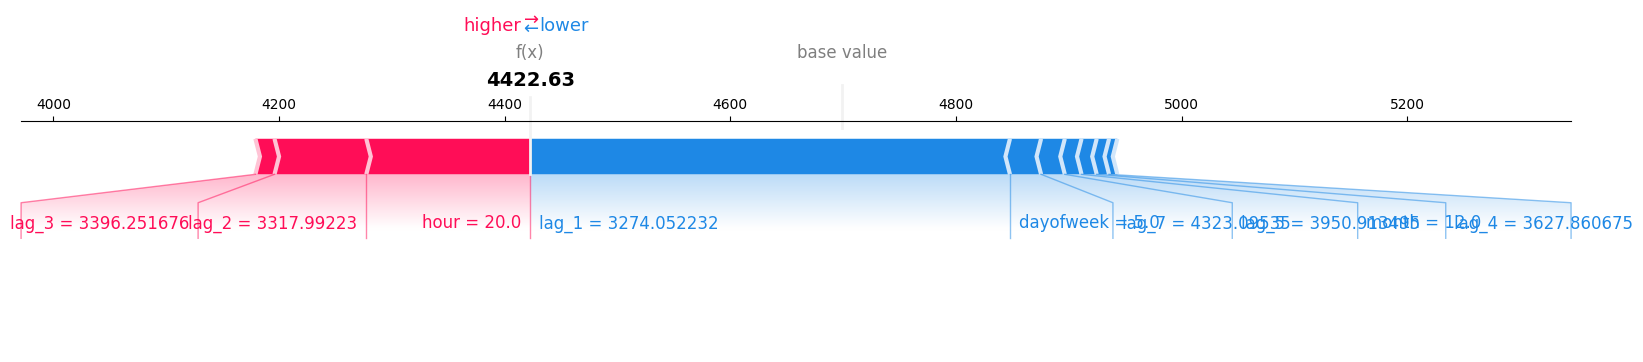

In [ ]:
# Force plot for the first observation (Statis)
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_train.iloc[0, :],
    matplotlib=True
)

### SHAP Dependence Plot — Analisis Temperature

Visualisasi ini digunakan untuk melihat pengaruh fitur **Temperature** terhadap hasil prediksi model serta interaksinya dengan fitur **lag_1**. Grafik membantu memahami bagaimana perubahan suhu memengaruhi nilai prediksi dan mengungkap pola hubungan yang mungkin bersifat non-linear.

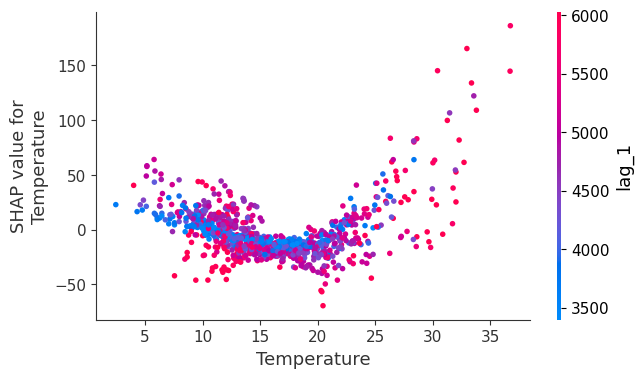

In [ ]:
# Menyiapkan fitur training dari forecaster
X_train_prepared, _ = forecaster.create_train_X_y(
    y=data_train['Demand'],
    exog=data_train[exog_cols]
)

# Menghapus baris yang mengandung NaN akibat pembuatan lag
X_train_clean = X_train_prepared.dropna()

# Mengambil 1000 sampel untuk analisis SHAP
X_sample = X_train_clean.sample(n=1000, random_state=42)

# Menghitung nilai SHAP
explainer = shap.TreeExplainer(internal_model)
shap_values = explainer.shap_values(X_sample)

# Membuat SHAP Dependence Plot
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot(
    ind="Temperature",
    shap_values=shap_values,
    features=X_sample,
    interaction_index="lag_1",
    ax=ax
)

### Analisis Pengaruh Fitur terhadap Prediksi (Partial Dependence Plot / PDP)

Grafik ini menunjukkan pengaruh rata-rata dari fitur **Temperature** dan **lag_1** terhadap hasil prediksi model, dengan asumsi fitur lainnya dianggap konstan. Dengan cara ini, kita dapat memahami bagaimana setiap fitur secara terpisah memengaruhi output prediksi.

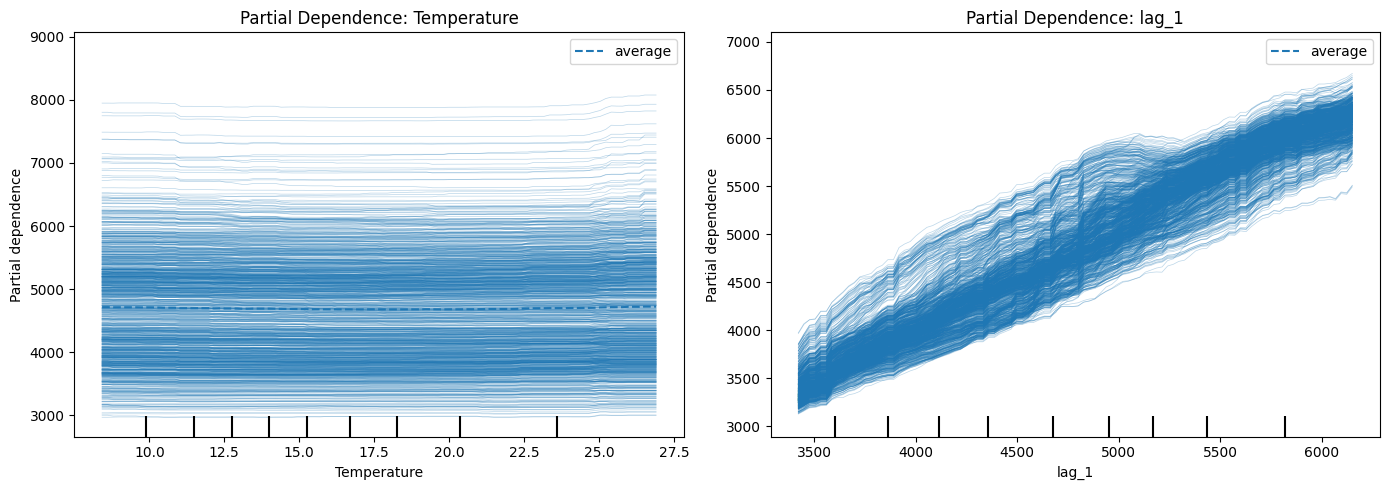

In [115]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Membuat 2 subplot untuk PDP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PDP untuk Temperature
PartialDependenceDisplay.from_estimator(
    forecaster.regressor,
    X_train_clean,
    features=["Temperature"],
    kind="both",
    ax=ax1
)
ax1.set_title("Partial Dependence: Temperature")
ax1.legend_.set_visible(False) if ax1.legend_ else None

# PDP untuk lag_1
PartialDependenceDisplay.from_estimator(
    forecaster.regressor,
    X_train_clean,
    features=["lag_1"],
    kind="both",
    ax=ax2
)
ax2.set_title("Partial Dependence: lag_1")
ax2.legend_.set_visible(False) if ax2.legend_ else None

# Merapikan layout
fig.tight_layout()
plt.show()

## 10. Nilai Prediksi dan Interpretabilitas Model (SHAP)

In [109]:
# Prediksi 10 langkah ke depan
predictions = forecaster.predict(steps=10, exog=data_test[exog_cols])

# Data fitur yang digunakan untuk prediksi
X_predict = forecaster.create_predict_X(steps=10, exog=data_test[exog_cols])

X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,hour,dayofweek,month,Temperature
2014-09-12 22:00:00+00:00,4101.132394,3924.172242,3626.332024,3506.563667,3557.567004,3745.282311,4097.708871,22.0,4.0,9.0,8.05
2014-09-12 23:00:00+00:00,4401.078031,4101.132394,3924.172242,3626.332024,3506.563667,3557.567004,3745.282311,23.0,4.0,9.0,10.80
2014-09-13 00:00:00+00:00,4505.588085,4401.078031,4101.132394,3924.172242,3626.332024,3506.563667,3557.567004,0.0,5.0,9.0,14.45
2014-09-13 01:00:00+00:00,4445.219878,4505.588085,4401.078031,4101.132394,3924.172242,3626.332024,3506.563667,1.0,5.0,9.0,15.80
2014-09-13 02:00:00+00:00,4345.749181,4445.219878,4505.588085,4401.078031,4101.132394,3924.172242,3626.332024,2.0,5.0,9.0,16.20
2014-09-13 03:00:00+00:00,4238.900922,4345.749181,4445.219878,4505.588085,4401.078031,4101.132394,3924.172242,3.0,5.0,9.0,17.15
2014-09-13 04:00:00+00:00,4171.324053,4238.900922,4345.749181,4445.219878,4505.588085,4401.078031,4101.132394,4.0,5.0,9.0,18.30
2014-09-13 05:00:00+00:00,4135.959034,4171.324053,4238.900922,4345.749181,4445.219878,4505.588085,4401.078031,5.0,5.0,9.0,17.60
2014-09-13 06:00:00+00:00,4186.298531,4135.959034,4171.324053,4238.900922,4345.749181,4445.219878,4505.588085,6.0,5.0,9.0,16.35
2014-09-13 07:00:00+00:00,4302.936764,4186.298531,4135.959034,4171.324053,4238.900922,4345.749181,4445.219878,7.0,5.0,9.0,15.70


In [ ]:
# Menghitung nilai SHAP untuk data prediksi
shap_values_pred = explainer.shap_values(X_predict)

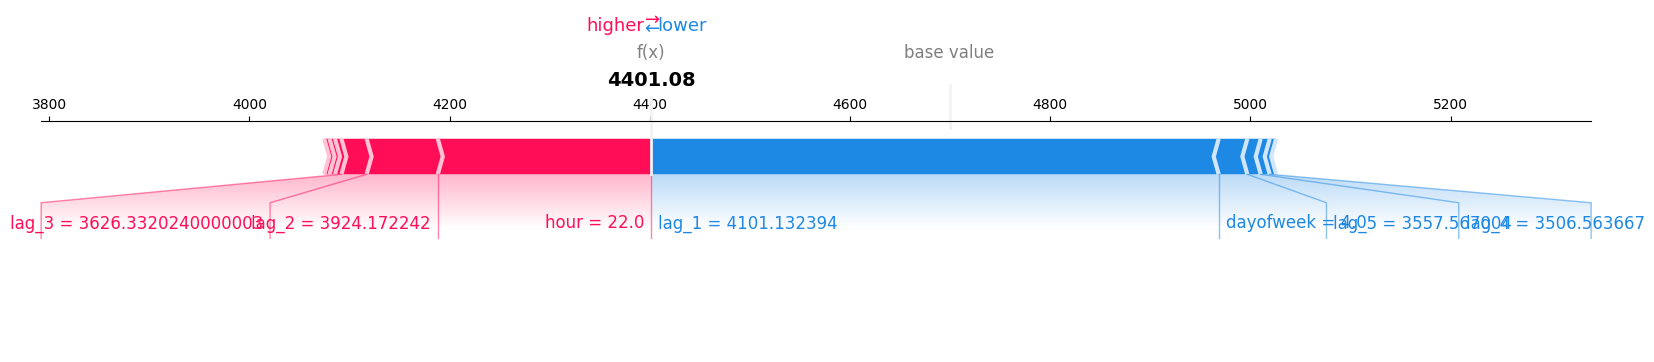

In [ ]:
# Memilih data prediksi pertama
iloc_predicted_date = 0

# Visualisasi SHAP untuk menjelaskan hasil prediksi
shap.force_plot(
    explainer.expected_value,
    shap_values_pred[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :],
    matplotlib=True
)

## 11. Prediksi & Evaluasi Model

In [ ]:
# Melakukan prediksi pada seluruh data testing
predictions = forecaster.predict(
    steps = len(data_test),
    exog  = data_test[exog_cols]
)

# Menghitung metrik evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = data_test['Demand'].values
y_pred = predictions.values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Menampilkan hasil evaluasi performa model
print(f"{'='*40}")
print(f"  Evaluasi Model pada Data Test")
print(f"{'='*40}")
print(f"  MAE  : {mae:,.2f} MW")
print(f"  RMSE : {rmse:,.2f} MW")
print(f"  MAPE : {mape:.2f}%")
print(f"{'='*40}")

  Evaluasi Model pada Data Test
  MAE  : 229.24 MW
  RMSE : 348.17 MW
  MAPE : 5.25%


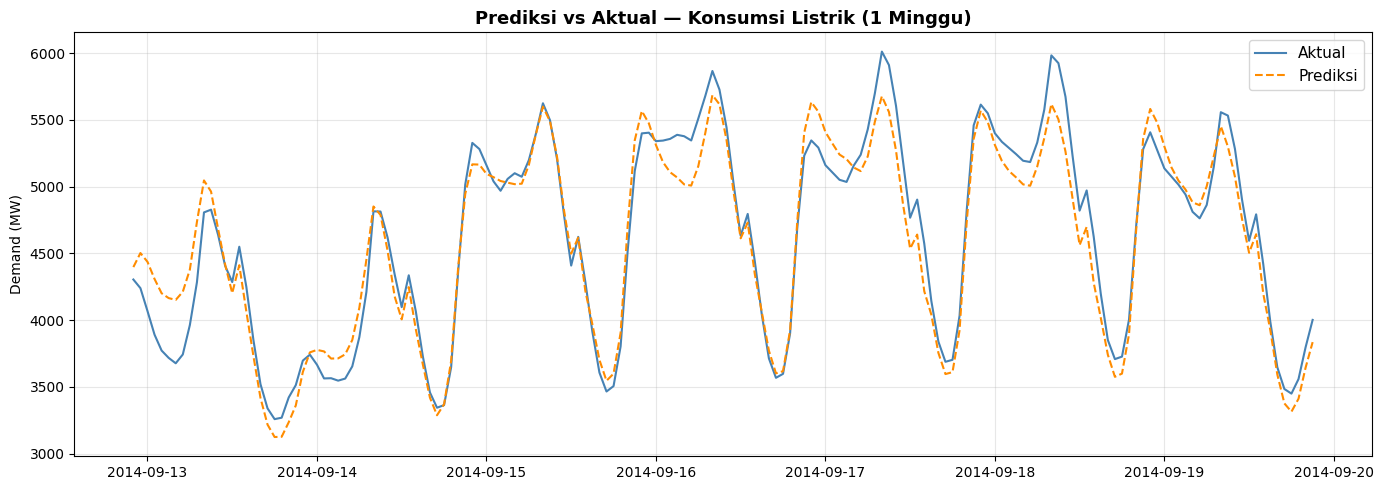

In [ ]:
# Menampilkan perbandingan data aktual dan hasil prediksi selama 1 minggu
n_plot = 24 * 7  # 1 minggu

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data_test['Demand'].iloc[:n_plot], 
        label='Aktual', color='steelblue', linewidth=1.5)
ax.plot(predictions.iloc[:n_plot], 
        label='Prediksi', color='darkorange', linewidth=1.5, linestyle='--')

# Menambahkan judul, label, dan legenda grafik
ax.set_title('Prediksi vs Aktual — Konsumsi Listrik (1 Minggu)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Ringkasan Proses Analisis


### Kesimpulan Hasil Analisis

| Metode | Hasil Utama |
| :--- | :--- |
| **Feature Importance** | Fitur **`lag_1`** dan **`lag_7`** menjadi fitur yang paling berpengaruh dalam proses prediksi. Hal ini menunjukkan bahwa konsumsi listrik pada 1 jam dan 7 jam sebelumnya (sistem lag 1-7) sangat membantu model dalam memetakan tren peramalan. |
| **SHAP Values** | Fitur **`hour` (jam)** dan **`lag_1`** memiliki kontribusi lokal yang besar terhadap hasil prediksi. Jam-jam tertentu secara spesifik dapat mendorong naik atau menekan turun nilai prediksi konsumsi listrik sesuai dengan fluktuasi pola harian. |
| **Permutation Importance** | Ketika fitur utama seperti **`lag_1`** dan **`hour`** diacak secara acak, performa model langsung mengalami penurunan drastis. Ini membuktikan ketergantungan kuat model terhadap kedua fitur tersebut. |
| **Partial Dependence Plot (PDP)** | Grafik 2x2 mengonfirmasi hubungan linear naik pada fitur **`lag_1`** dan **`lag_7`**, serta menangkap pola naik-turun yang jelas pada fitur waktu (**`hour`** dan **`dayofweek`**) sesuai dengan siklus aktivitas manusia. |



### Mengapa Explainability Penting?

1. **Memahami Cara Kerja Model:** Hasil prediksi tidak lagi dianggap sebagai angka keluaran mistis dari sebuah kotak hitam (*black-box model*), melainkan keputusan rasional berbasis data.
2. **Meningkatkan Kepercayaan Pengguna:** Faktor-faktor penggerak utama yang memengaruhi naik-turunnya prediksi konsumsi listrik dapat dibuktikan dan divalidasi secara visual.
3. **Membantu Proses Debugging:** Memudahkan praktisi data ketika model menghasilkan prediksi yang aneh, karena kita bisa melacak fitur mana yang menjadi biang keladinya (misal menggunakan SHAP Force Plot).
4. **Efisiensi Pengembangan Model:** Fitur yang terbukti tidak berpengaruh (seperti variabel `Temperature` yang grafiknya cenderung flat) dapat dipertimbangkan untuk dieliminasi guna meringankan beban komputasi model.
5. **Transparansi dan Audit Model:** Sangat krusial untuk sektor publik atau industri energi/utilitas yang membutuhkan akuntabilitas tinggi dalam perencanaan distribusi daya listrik.



### Kesimpulan Akhir

Berdasarkan hasil analisis ulang pada notebook *Skforecast Model Explainability*, model forecasting berbasis LightGBM berhasil memanfaatkan struktur data historis deret waktu untuk memprediksi konsumsi listrik di masa depan secara akurat. Fitur berbasis pola riwayat murni (**`lag_1`** dan **`lag_7`**) serta fitur berbasis waktu (**`hour`** dan **`dayofweek`**) terbukti secara konsisten menjadi fondasi utama model dalam mengambil keputusan.

Melalui integrasi metode *Machine Learning Explainability* (**Feature Importance, SHAP, Permutation Importance,** dan **PDP**), proyek ini berhasil menjembatani celah antara akurasi prediksi yang tinggi dan transparansi model. Hasilnya, model forecasting ini siap dipertanggungjawabkan dan sangat andal untuk mendukung sistem pengambilan keputusan (*decision support system*) manajemen beban energi.